In [ ]:
!pip install adjustText

In [ ]:
import pandas as pd
import sys
import matplotlib.pyplot as plt
from adjustText import adjust_text


In [ ]:
# Change this to the desired folder location
IMAGE_FOLDER = './pattern_data/double_addi/no_ext.ResNet50/'
from pathlib import Path
Path(IMAGE_FOLDER).mkdir(parents=True, exist_ok=True)

In [ ]:
# Function to check if a pattern is covered
def is_covered(pattern):
    try:
        first, second = map(int, pattern.split('_'))  # Split pattern into two numbers
        return (0 <= first < 32) and (0 <= second < 1024)
    except ValueError:
        return False

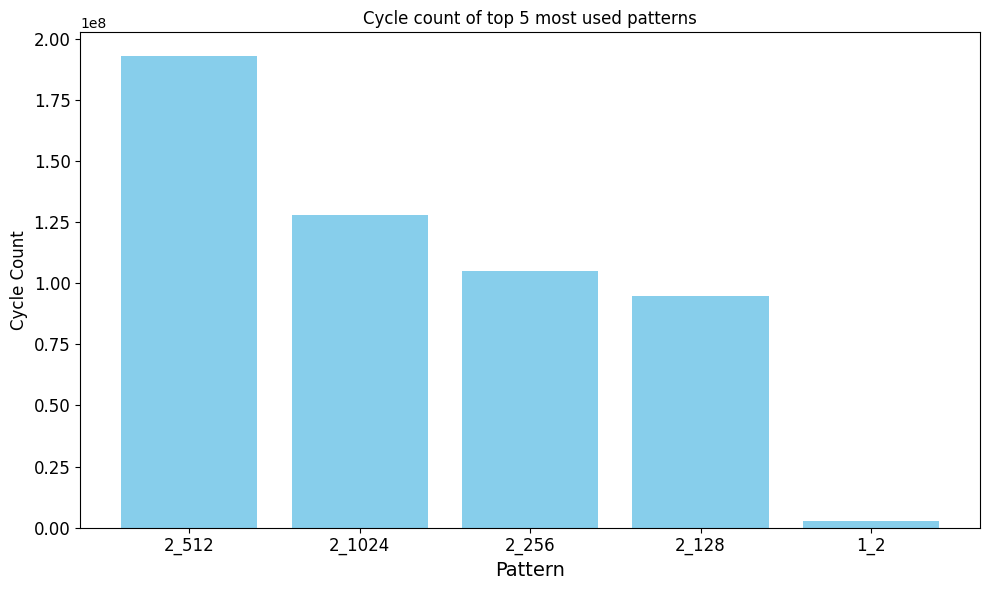

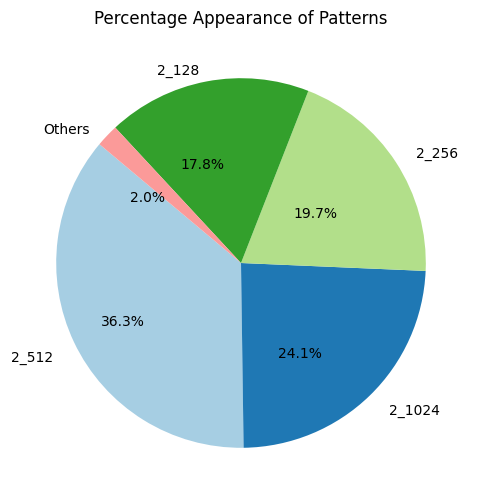

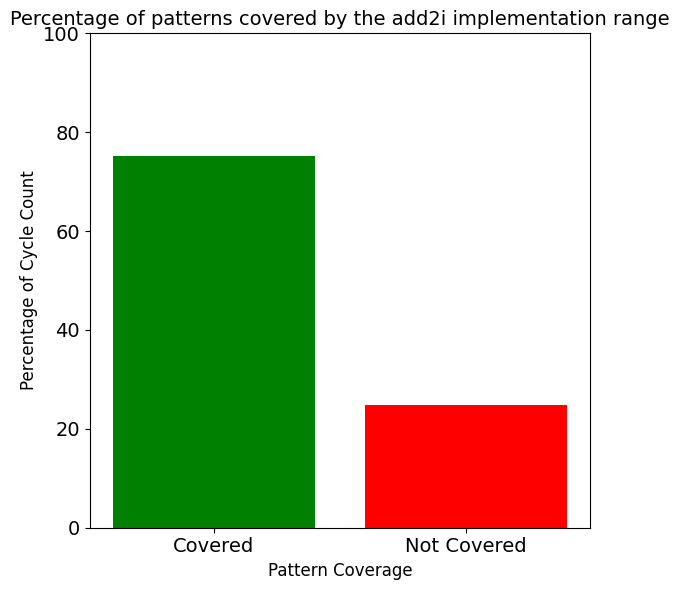

,pattern,cycle_count,covered
13,2_512,192937984,True
22,2_1024,127926272,False
86,2_256,104857600,True
75,2_128,94765056,True
8,1_2,2650518,True
...,...,...,...
1,24_-1975,1,False
184,384_437,0,False
182,8_-1868,0,False
187,24_100,0,True


530995267


In [ ]:
# Change this to the file with the pattern counts desired
file_path = "./profiling_data/double_addi_patterns.no_ext.ResNet50.03-03-25.csv"
df = pd.read_csv(file_path)
df.sort_values('cycle_count', inplace=True, ascending=False)
# Plot a bar chart
plt.figure(figsize=(10, 6))
top_N = 5
plt.bar(df.head(top_N)['pattern'], df.head(top_N)['cycle_count'], color='skyblue')

plt.xlabel('Pattern', fontsize=14)
plt.ylabel('Cycle Count', fontsize=12)

plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)
title = str('Cycle count of top ' + str(top_N) + ' most used patterns')
plt.title(title)
plt.tight_layout()
plt.savefig(str(IMAGE_FOLDER + 'cycle_count_bar.png'))
plt.show()
#====================================================
top_N = 4

# Get the top 10 patterns
top_10 = df.head(top_N)

others_count = df['cycle_count'].sum() - top_10['cycle_count'].sum()

# Create a new dataframe for the pie chart, including the "Others" category
pie_data = top_10[['pattern', 'cycle_count']].copy()
if others_count > 0:
    pie_data.loc[len(pie_data.index)] = ['Others', others_count]

from adjustText import adjust_text

plt.figure(figsize=(10, 6))
wedges, texts, autotexts = plt.pie(
    pie_data['cycle_count'],
    labels=pie_data['pattern'],
    autopct='%1.1f%%',
    colors=plt.cm.Paired.colors,
    startangle=140
)

# Adjust text positions
adjust_text(texts + autotexts, expand=(1.2, 1.5))

plt.title('Percentage Appearance of Patterns')
plt.savefig(str(IMAGE_FOLDER + 'percentage_pie.png'))
plt.show()


#====================================================
# Apply the function to categorize each pattern
df['covered'] = df['pattern'].apply(is_covered)

# Aggregate the cycle counts for covered and not covered patterns
coverage_counts = df.groupby('covered')['cycle_count'].sum()

# Calculate total cycle count
total_cycle_count = coverage_counts.sum()

# Compute percentages
percentages = (coverage_counts / total_cycle_count) * 100

labels = ['Covered', 'Not Covered']
values = [percentages.get(True, 0), percentages.get(False, 0)]

# Create the bar chart with percentages
plt.figure(figsize=(6, 6))
bars = plt.bar(labels, values, color=['green', 'red'])

# Add percentage labels on top of bars
# for bar, percent in zip(bars, values):
#     plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() -4, f'{percent:.1f}%', ha='center', fontsize=12)

plt.xlabel('Pattern Coverage', fontsize=12)
plt.ylabel('Percentage of Cycle Count', fontsize=12)
plt.title('Percentage of patterns covered by the add2i implementation range', fontsize=14)

plt.ylim(0, 100)
# Adjust fontsize
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.savefig(str(IMAGE_FOLDER + 'coverage_bar.png'))
plt.show()

display(df)
print(df['cycle_count'].sum())